In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# CARGAMOS DATASET DE CIFAR-10

In [ ]:
(x_train,y_train),(x_test,y_test) = keras.datasets.cifar10.load_data()


# MOSTRAMOS UNA IMAGEN ALEATORIA

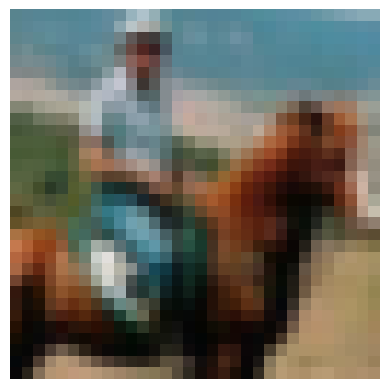

In [ ]:
# Seleccionar un índice aleatorio
idx = np.random.randint(0, len(x_train))

# Mostrar la imagen
plt.imshow(x_train[idx])
plt.axis('off')  # Ocultar ejes
plt.show()

# NORMALIZAR VALORES Y ESCALAR

In [ ]:
# Normalizar los valores de píxeles a [0,1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convertir etiquetas a one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# CREAMOS EL MODELO DE RED CONVOLUCIONAL

In [ ]:
class_names = ['avión', 'auto', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']

model = keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    keras.layers.MaxPool2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# COMPILAMOS EL MODELO

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ENTRENAMOS EL MODELO

In [ ]:
history = model.fit(x_train,y_train,epochs=10,batch_size=64,validation_data=(x_test,y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 144ms/step - accuracy: 0.2977 - loss: 1.8996 - val_accuracy: 0.5488 - val_loss: 1.2398
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 136s 137ms/step - accuracy: 0.5344 - loss: 1.2985 - val_accuracy: 0.6326 - val_loss: 1.0417
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 110s 140ms/step - accuracy: 0.6138 - loss: 1.1020 - val_accuracy: 0.6801 - val_loss: 0.9200
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 135ms/step - accuracy: 0.6657 - loss: 0.9601 - val_accuracy: 0.7114 - val_loss: 0.8367
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 135ms/step - accuracy: 0.6957 - loss: 0.8707 - val_accuracy: 0.7263 - val_loss: 0.8017
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 134ms/step - accuracy: 0.7190 - loss: 0.8076 - val_accuracy: 0.7151 - val_loss: 0.8139
Epoch 7/10
355/782 ━━━━━━━━━━━━━━━━━━━━ 53s 126ms/step - accuracy: 0.7441 - loss: 0.7508

# EVALUAMOS EL MODELO

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nPrecisión en test: {test_acc * 100:.2f}%')

# 6. Graficar precisión y pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid()

plt.show()

# MOSTRAMOS ALGUNAS IMAGENES CON SUS PREDICCIONES


In [ ]:
def mostrar_predicciones(model, x_test, y_test, class_names):
    plt.figure(figsize=(10,5))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        img = x_test[i]
        true_label = np.argmax(y_test[i])
        pred_label = np.argmax(model.predict(img.reshape(1, 32, 32, 3)))

        plt.imshow(img)
        plt.title(f'Real: {class_names[true_label]}\nPred: {class_names[pred_label]}', fontsize=10)
        plt.axis('off')
    plt.show()

mostrar_predicciones(model, x_test, y_test, class_names)